### Imports

In [ ]:
import os
import re
import glob
import random
import sys
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

from PIL import Image
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch.optim import AdamW
from torch.utils.data import DataLoader, Sampler, Subset
from torchmetrics.classification import BinaryAccuracy
from torchvision import datasets, models, transforms
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
)

from pytorch_lightning.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)

### Dataset

In [ ]:
# Dataset
pat = "2_png_224"

# All weights and saved models go here
WEIGHTS_DIR = "Transfer_learning/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Tables
TABLE_PATH = "tabela_features_final.csv"

ID_COL = "ID"
LABEL_COL = "label"

# Model
model_name = "facebook/deit-base-patch16-224"
model = AutoModelForImageClassification.from_pretrained(model_name)

# Unfreeze last blocks + LayerNorm + classifier

In [ ]:
# 1. Switch to 1 output logit
model.config.num_labels = 1
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 1)

# 2. Freeze everything
for param in model.parameters():
    param.requires_grad = False

# 3. Unfreeze last 3 transformer blocks
for block in model.vit.encoder.layer[-3:]:
    for param in block.parameters():
        param.requires_grad = True

# 4. Unfreeze final LayerNorm
for param in model.vit.layernorm.parameters():
    param.requires_grad = True

# 5. Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Total params:     {total:,}")
print(f"Trainable %:      {100 * trainable / total:.4f}%")

## Augmentation and Dataloader

In [ ]:
# BalancedBatchSampler: always 50/50 batches
class BalancedBatchSampler(Sampler):
    def __init__(self, dataset, batch_size):
        self.dataset    = dataset
        self.batch_size = batch_size
        self.targets    = torch.tensor(dataset.targets)
        assert batch_size % 2 == 0, "batch_size must be even"
        self.class0_idx     = torch.where(self.targets == 0)[0].tolist()
        self.class1_idx     = torch.where(self.targets == 1)[0].tolist()
        self.min_class_size = min(len(self.class0_idx), len(self.class1_idx))
        self.num_batches    = self.min_class_size // (batch_size // 2)

    def __iter__(self):
        random.shuffle(self.class0_idx)
        random.shuffle(self.class1_idx)
        for i in range(self.num_batches):
            batch0 = self.class0_idx[i*(self.batch_size//2):(i+1)*(self.batch_size//2)]
            batch1 = self.class1_idx[i*(self.batch_size//2):(i+1)*(self.batch_size//2)]
            batch  = batch0 + batch1
            random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches


# Transforms: fixed center-crop zoom levels
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomChoice([
        transforms.RandomRotation((0,   0)),
        transforms.RandomRotation((90,  90)),
        transforms.RandomRotation((180, 180)),
        transforms.RandomRotation((270, 270)),
    ]),
    transforms.RandomChoice([
        transforms.Compose([]),
        transforms.Compose([transforms.CenterCrop(179), transforms.Resize(224)]),
        transforms.Compose([transforms.CenterCrop(150), transforms.Resize(224)]),
        transforms.Compose([transforms.CenterCrop(112), transforms.Resize(224)]),
    ]),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(root=f"{pat}/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=f"{pat}/val",   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(root=f"{pat}/test",  transform=eval_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_sampler=BalancedBatchSampler(train_dataset, batch_size), num_workers=20)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=20)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=20)

print("Classes:", train_dataset.classes)
print("Train:",   len(train_dataset))
print("Val:",     len(val_dataset))
print("Test:",    len(test_dataset))

In [ ]:
# LightningModule: BCE + Binary Accuracy
from torchmetrics.classification import BinaryAccuracy

class LitViT(pl.LightningModule):
    def __init__(self, model, lr=3e-5, weight_decay=0.01):
        super().__init__()
        self.model = model
        self.save_hyperparameters(ignore=["model"])
        self.criterion = nn.BCEWithLogitsLoss()
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()

    def forward(self, x):
        return self.model(pixel_values=x).logits.squeeze(1)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss   = self.criterion(logits, labels.float())
        self.train_acc.update(torch.sigmoid(logits), labels)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_acc", self.train_acc.compute(), prog_bar=True)
        self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss   = self.criterion(logits, labels.float())
        self.val_acc.update(torch.sigmoid(logits), labels)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def on_validation_epoch_end(self):
        self.log("val_acc", self.val_acc.compute(), prog_bar=True)
        self.val_acc.reset()

    def configure_optimizers(self):
        return AdamW(filter(lambda p: p.requires_grad, self.parameters()),
                     lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

In [ ]:
# Training
lit_vit = LitViT(model)

ckpt_vit = ModelCheckpoint(
    dirpath=WEIGHTS_DIR,
    filename="vit-{epoch:03d}-{val_acc:.4f}",
    monitor="val_acc",
    mode="max",
    save_top_k=1
)

early_stop = EarlyStopping(
    monitor="val_acc",
    mode="max",
    patience=15,
    min_delta=1e-4,
    verbose=True
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10,
    logger=pl.loggers.TensorBoardLogger("tb_logs", name="deit"),
    callbacks=[ckpt_vit, early_stop]
)

trainer.fit(lit_vit, train_loader, val_loader)
print("Best ViT checkpoint:", ckpt_vit.best_model_path)

---
# Inference & Ensemble
> Standalone section — loads the trained checkpoint and builds the tabular + ViT stacking ensemble.

In [ ]:
import os, re, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import joblib
import pytorch_lightning as pl
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from transformers import AutoModelForImageClassification
from torchmetrics.classification import BinaryAccuracy
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier

SEED        = 42
# Dataset
pat = "2_png_224"

# Tables
TABLE_PATH = "tabela_features_final.csv"

ID_COL = "ID"
LABEL_COL = "label"
model_name  = "facebook/deit-base-patch16-224"
WEIGHTS_DIR = "Transfer_learning/weights"

pl.seed_everything(SEED)

Seed set to 42


42

In [8]:
# LitViT definition (required to load checkpoint)
class LitViT(pl.LightningModule):
    def __init__(self, model, lr=3e-5, weight_decay=0.01):
        super().__init__()
        self.model = model
        self.save_hyperparameters(ignore=["model"])
        self.criterion = nn.BCEWithLogitsLoss()
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()

    def forward(self, x):
        return self.model(pixel_values=x).logits.squeeze(1)

    def configure_optimizers(self):
        return AdamW(filter(lambda p: p.requires_grad, self.parameters()),
                     lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

# Load best checkpoint
ckpt_files = glob.glob(f"{WEIGHTS_DIR}/vit-*.ckpt")
best_ckpt  = max(ckpt_files, key=lambda p: float(p.split("val_acc=")[-1].replace(".ckpt", "")))
print("Loading:", best_ckpt)

base_model = AutoModelForImageClassification.from_pretrained(model_name)
base_model.config.num_labels = 1
base_model.classifier = nn.Linear(base_model.classifier.in_features, 1)

lit_vit_inf = LitViT.load_from_checkpoint(best_ckpt, model=base_model)
lit_vit_inf.eval()
print("Model loaded. Device:", next(lit_vit_inf.parameters()).device)

Loading: Transfer_learning/weights/vit-epoch=089-val_acc=0.9209.ckpt
Model loaded. Device: cuda:0


In [ ]:
# Transforms + Loaders
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        return img, label, self.samples[index][0]

def make_loader(root, batch_size=32, num_workers=4):
    ds = ImageFolderWithPaths(root=root, transform=eval_transforms)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

DR_ID_RE = re.compile(
    r"(DR\d+_\d+_STRIPE82-\d{4}_\d{7})",
    re.IGNORECASE
)

SHORT_ID_RE = re.compile(
    r"(i\d{2}s\d{2}s\d{5}[A-Za-z]{2})",
    re.IGNORECASE
)

BAND_SUFFIX_RE = re.compile(
    r"_(u|g|r|i|z|j0378|j0395|j0410|j0430|j0515|j0660|j0861)$",
    re.IGNORECASE
)


def normalize_object_id(value):
    """
    Normaliza IDs vindos tanto da tabela quanto do nome das imagens.

    Exemplos:
    Imagens_CG_2_MorphoSPLUS_962_DR4_3_STRIPE82-0044_0043726_r.png
    -> DR4_3_STRIPE82-0044_0043726

    ML_i06s25s22002RP_g.png
    -> i06s25s22002RP

    i06s20s33001OY
    -> i06s20s33001OY
    """

    s = str(value).strip().strip('"').strip("'")
    s = s.replace("\\", "/")
    s = os.path.basename(s)

    s = re.sub(r"\.[^.]+$", "", s)

    m = DR_ID_RE.search(s)
    if m:
        return m.group(1)

    m = SHORT_ID_RE.search(s)
    if m:
        return m.group(1)

    s = BAND_SUFFIX_RE.sub("", s)

    if s.startswith("ML_"):
        s = s[3:]

    return s.strip()


def object_id_from_path(path):
    return normalize_object_id(path)

train_loader_inf = make_loader(f"{pat}/train")
val_loader_inf   = make_loader(f"{pat}/val")
test_loader_inf  = make_loader(f"{pat}/test")
print("Train:", len(train_loader_inf.dataset),
      "| Val:", len(val_loader_inf.dataset),
      "| Test:", len(test_loader_inf.dataset))

Train: 4283 | Val: 1049 | Test: 1010



── ViT only [Val] ──
              precision    recall  f1-score   support

        Good       0.96      0.97      0.96       701
         Bad       0.77      0.73      0.75       105

    accuracy                           0.94       806
   macro avg       0.87      0.85      0.86       806
weighted avg       0.94      0.94      0.94       806



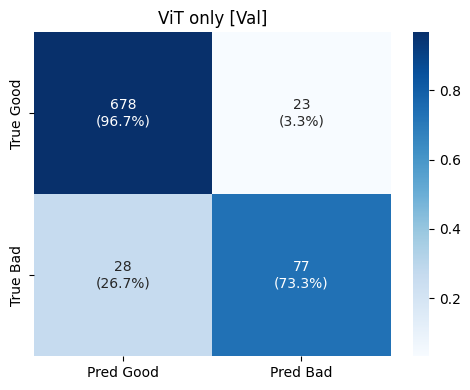


── ViT only [Test] ──
              precision    recall  f1-score   support

        Good       0.94      0.97      0.95       595
         Bad       0.77      0.66      0.71       102

    accuracy                           0.92       697
   macro avg       0.86      0.81      0.83       697
weighted avg       0.92      0.92      0.92       697



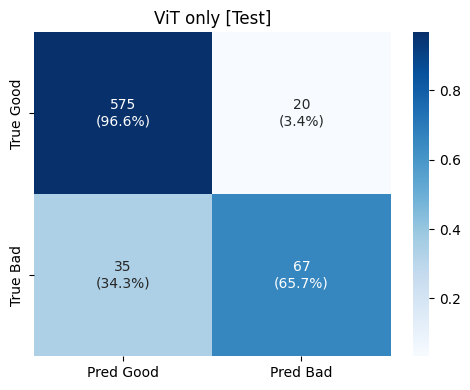

In [10]:
# ViT standalone evaluation
def plot_cm(cm, title):
    row_sums = cm.sum(axis=1, keepdims=True).astype(float); row_sums[row_sums==0] = 1
    cm_pct = cm / row_sums
    ann = [[f"{cm[i,j]}\n({cm_pct[i,j]*100:.1f}%)" for j in range(2)] for i in range(2)]
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_pct, annot=ann, fmt="", cmap="Blues", cbar=True,
                xticklabels=["Pred Good", "Pred Bad"],
                yticklabels=["True Good", "True Bad"])
    plt.title(title); plt.tight_layout(); plt.show()

def predict_probs(lit_model, dl, prob_col="vit_prob"):
    lit_model.eval()
    device = next(lit_model.parameters()).device
    rows = []
    with torch.inference_mode():
        for images, labels, paths in dl:
            images = images.to(device, non_blocking=True)
            probs  = torch.sigmoid(lit_model(images)).cpu().numpy()
            for prob, label, path in zip(probs, labels.numpy(), paths):
                rows.append({"object_id": object_id_from_path(str(path)),
                             "y_true": int(label), prob_col: float(prob)})
    df = pd.DataFrame(rows)
    return df.groupby("object_id", as_index=False).agg({prob_col: "mean", "y_true": "first"})

df_vit_val  = predict_probs(lit_vit_inf, val_loader_inf)
df_vit_test = predict_probs(lit_vit_inf, test_loader_inf)

for split, df_vit in [("Val", df_vit_val), ("Test", df_vit_test)]:
    y_true = df_vit["y_true"].values
    pred   = (df_vit["vit_prob"].values >= 0.5).astype(int)
    print(f"\n── ViT only [{split}] ──")
    print(classification_report(y_true, pred, target_names=["Good", "Bad"], zero_division=0))
    plot_cm(confusion_matrix(y_true, pred), f"ViT only [{split}]")

In [ ]:
def load_features_table(table_path, id_col="ID", label_col="label", require_label=True):
    df = pd.read_csv(table_path, low_memory=False)
    df.columns = df.columns.str.strip()

    if id_col not in df.columns:
        raise ValueError(f"Coluna de ID não encontrada: {id_col}")

    if require_label and label_col not in df.columns:
        raise ValueError(f"Coluna de label não encontrada: {label_col}")

    df["object_id"] = df[id_col].apply(normalize_object_id)

    if label_col in df.columns:
        df[label_col] = pd.to_numeric(df[label_col], errors="coerce")

        if require_label:
            df = df.dropna(subset=[label_col]).copy()
            df[label_col] = df[label_col].astype(int)

    text_cols = {
        "source_folder", "source_file",
        "ID", "ID_1", "ID_2", "id_2", "ID4",
        "Field_ID", "field", "field_1", "Field", "Dir_",
        "galaxy_id", "splus_id", "object_id"
    }

    if label_col in df.columns:
        text_cols.add(label_col)

    for col in df.columns:
        if col in text_cols:
            continue

        s = df[col].astype(str)
        s = s.str.replace("*", "", regex=False)
        s = s.str.replace(",", ".", regex=False)
        s = s.str.strip()
        s = s.replace({
            "nan": np.nan,
            "NaN": np.nan,
            "None": np.nan,
            "": np.nan
        })

        df[col] = pd.to_numeric(s, errors="coerce")

    if "z" not in df.columns and "redshift" in df.columns:
        df["z"] = df["redshift"]

    return df


df_table = load_features_table(
    TABLE_PATH,
    id_col=ID_COL,
    label_col=LABEL_COL,
    require_label=True
)

def ids_from_loader(dl):
    ids = set()
    for _, _, paths in dl:
        ids.update(object_id_from_path(str(p)) for p in paths)
    return ids

train_ids = ids_from_loader(train_loader_inf)
val_ids   = ids_from_loader(val_loader_inf)
test_ids  = ids_from_loader(test_loader_inf)

df_train = df_table[df_table["object_id"].isin(train_ids)].copy()
df_val   = df_table[df_table["object_id"].isin(val_ids)].copy()
df_test  = df_table[df_table["object_id"].isin(test_ids)].copy()

print("Unique objects:")
print("Train:", len(train_ids))
print("Val:  ", len(val_ids))
print("Test: ", len(test_ids))

print("\nObjects found in the table:")
print("Train:", len(df_train))
print("Val:  ", len(df_val))
print("Test: ", len(df_test))

missing_train = train_ids - set(df_table["object_id"])
missing_val   = val_ids   - set(df_table["object_id"])
missing_test  = test_ids  - set(df_table["object_id"])

print("\nIDs of objects missing from the table:")
print("Train:", len(missing_train))
print("Val:  ", len(missing_val))
print("Test: ", len(missing_test))

if len(df_train) == 0:
    raise ValueError("ID not found in the table.")

if len(df_val) == 0:
    raise ValueError("ID not found in the table.")

if len(df_test) == 0:
    raise ValueError("Nenhum ID de teste foi encontrado na tabela.")

y_train = df_train["label"].values
y_val   = df_val["label"].values
y_test  = df_test["label"].values

# numeric_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns if c != "label"]
# features_all = [c for c in numeric_cols if df_train[c].notna().sum() >= 30 and df_train[c].nunique() >= 2]

# resultados = []
# for col in features_all:
#     mask = df_train[col].notna().values
#     if mask.sum() < 200: continue
#     x_sub, y_sub = df_train.loc[mask, col].values, y_train[mask]
#     if len(np.unique(y_sub)) < 2: continue
#     try:
#         auc = roc_auc_score(y_sub, x_sub)
#         resultados.append([col, max(auc, 1 - auc)])
#     except: pass

# df_auc   = pd.DataFrame(resultados, columns=["feature", "auc_sep"]).sort_values("auc_sep", ascending=False)
# auc_dict = dict(zip(df_auc["feature"], df_auc["auc_sep"]))
# features_boas = df_auc[df_auc["auc_sep"] > 0.60]["feature"].tolist()

# remover  = set()
# corr_abs = df_train[features_boas].corr(method="pearson", min_periods=200).abs()
# for i in range(len(features_boas)):
#     for j in range(i + 1, len(features_boas)):
#         f1, f2 = features_boas[i], features_boas[j]
#         if f1 in remover or f2 in remover: continue
#         if corr_abs.loc[f1, f2] >= 0.90:
#             remover.add(f2 if auc_dict[f1] >= auc_dict[f2] else f1)

# features_sel = [f for f in features_boas if f not in remover]
# print(f"Selected tabular features: {len(features_sel)}")
# print(features_sel)

features_sel = [####FEATURES SELECTED######]

Selected tabular features: 24
['MAG_Z', 'MAG_J0660', 'MAG_J0861', 'CHI2NU', 'MAG_J0515', 'J0861_auto', 'J0515_auto', 'A', 'MAG_J0430', 'u_auto', 'J0430_auto', 'MAG_U', 'e_AR_Z', 'e_i_auto', 'MAG_J0395', 'J0410_auto', 'B', 'J0395_auto', 'e_J0861_auto', 'FLUX_RADIUS_50', 'FLUX_RADIUS_90', 'J0378_auto', 'e_J0395_auto', 'RE_R']



── BRF tabular [Val] ──
              precision    recall  f1-score   support

        Good       1.00      0.88      0.94       701
         Bad       0.56      0.99      0.71       105

    accuracy                           0.90       806
   macro avg       0.78      0.94      0.83       806
weighted avg       0.94      0.90      0.91       806



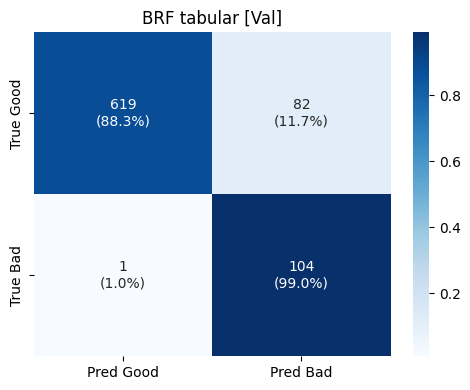


── BRF tabular [Test] ──
              precision    recall  f1-score   support

        Good       1.00      0.88      0.93       595
         Bad       0.58      0.99      0.73       102

    accuracy                           0.90       697
   macro avg       0.79      0.93      0.83       697
weighted avg       0.94      0.90      0.91       697



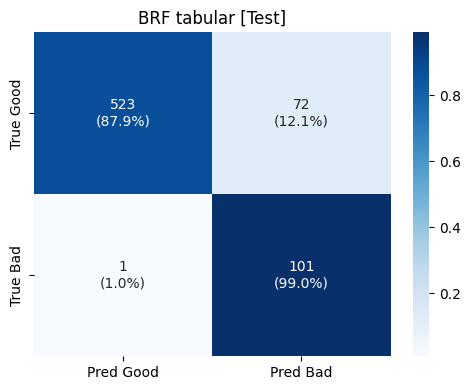

In [12]:
# Balanced Random Forest (tabular)
def make_rf_pipeline(seed=SEED):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", BalancedRandomForestClassifier(
            n_estimators=1000, random_state=seed, n_jobs=-1, min_samples_leaf=2
        ))
    ])

rf_tab = make_rf_pipeline()
rf_tab.fit(df_train[features_sel], y_train)

for split, X, y in [("Val", df_val[features_sel], y_val), ("Test", df_test[features_sel], y_test)]:
    prob = rf_tab.predict_proba(X)[:, 1]
    pred = (prob >= 0.5).astype(int)
    print(f"\n── BRF tabular [{split}] ──")
    print(classification_report(y, pred, target_names=["Good", "Bad"], zero_division=0))
    plot_cm(confusion_matrix(y, pred), f"BRF tabular [{split}]")

Stacking weights:
  BRF: 7.9045
  ViT: 3.5246

── Stacking BRF + ViT [Val] ──
              precision    recall  f1-score   support

        Good       1.00      0.96      0.98       701
         Bad       0.80      0.97      0.88       105

    accuracy                           0.97       806
   macro avg       0.90      0.97      0.93       806
weighted avg       0.97      0.97      0.97       806



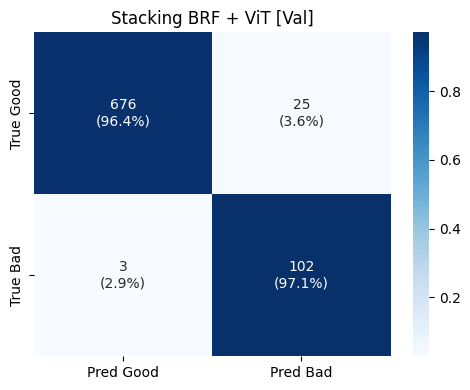


── Stacking BRF + ViT [Test] ──
              precision    recall  f1-score   support

        Good       1.00      0.96      0.98       595
         Bad       0.80      0.98      0.88       102

    accuracy                           0.96       697
   macro avg       0.90      0.97      0.93       697
weighted avg       0.97      0.96      0.96       697



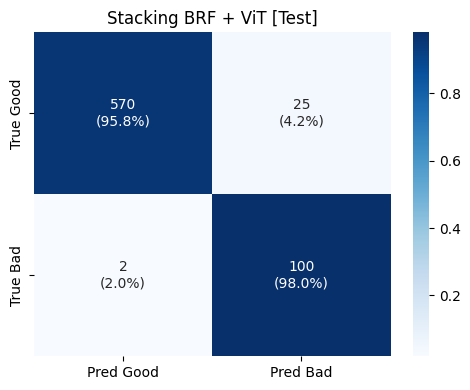

In [13]:
# Stacking Ensemble: BRF + ViT
# Meta-model trained on VAL, evaluated on VAL and TEST

# df_vit_val / df_vit_test already computed above
df_vit_train = predict_probs(lit_vit_inf, train_loader_inf)

def get_vit_probs(df_split, df_vit):
    return df_split[["object_id"]].merge(df_vit, on="object_id", how="left")["vit_prob"].fillna(0.5).values

vit_val  = get_vit_probs(df_val,  df_vit_val)
vit_test = get_vit_probs(df_test, df_vit_test)

brf_val  = rf_tab.predict_proba(df_val[features_sel])[:, 1]
brf_test = rf_tab.predict_proba(df_test[features_sel])[:, 1]

X_meta_val  = np.column_stack([brf_val,  vit_val])
X_meta_test = np.column_stack([brf_test, vit_test])

meta = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
meta.fit(X_meta_val, y_val)

print("Stacking weights:")
for name, w in zip(["BRF", "ViT"], meta.coef_[0]):
    print(f"  {name}: {w:.4f}")

for split, X_meta, y_true in [("Val", X_meta_val, y_val), ("Test", X_meta_test, y_test)]:
    prob = meta.predict_proba(X_meta)[:, 1]
    pred = (prob >= 0.5).astype(int)
    print(f"\n── Stacking BRF + ViT [{split}] ──")
    print(classification_report(y_true, pred, target_names=["Good", "Bad"], zero_division=0))
    plot_cm(confusion_matrix(y_true, pred), f"Stacking BRF + ViT [{split}]")

In [14]:
# Save all trained models to weights dir
import joblib

joblib.dump(rf_tab,       f"{WEIGHTS_DIR}/brf_tabular.pkl")
joblib.dump(meta,         f"{WEIGHTS_DIR}/meta_lr.pkl")
joblib.dump(features_sel, f"{WEIGHTS_DIR}/features_sel.pkl")

print("Saved to:", WEIGHTS_DIR)
print("  brf_tabular.pkl")
print("  meta_lr.pkl")
print("  features_sel.pkl")
print("  vit-*.ckpt  (saved during training by ModelCheckpoint)")

Saved to: Transfer_learning/weights
  brf_tabular.pkl
  meta_lr.pkl
  features_sel.pkl
  vit-*.ckpt  (saved during training by ModelCheckpoint)


---
# Prediction on New Dataset
> Standalone section — loads saved BRF, ViT and meta-model to run predictions on new images and table. Labels are not required.

In [ ]:
# Paths - adjust for your new dataset
NEW_IMG_DIR  = "png_224_new"                          # image folder (needs at least one subfolder)
NEW_TABLE    = "combined_GalfitM_output_c.csv"                    # morphological features table
NEW_ID_COL   = "ID"                                 # ID column in the new table
OUTPUT_CSV   = "Transfer_learning/predictions_new.csv"
WEIGHTS_DIR  = "Transfer_learning/weights"
model_name   = "facebook/deit-base-patch16-224"
SEED         = 42

pl.seed_everything(SEED)

Seed set to 42


42

In [ ]:
# Load ViT
class LitViT(pl.LightningModule):
    def __init__(self, model, lr=3e-5, weight_decay=0.01):
        super().__init__()
        self.model = model
        self.save_hyperparameters(ignore=["model"])
        self.criterion = nn.BCEWithLogitsLoss()
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()

    def forward(self, x):
        return self.model(pixel_values=x).logits.squeeze(1)

    def configure_optimizers(self):
        return AdamW(filter(lambda p: p.requires_grad, self.parameters()),
                     lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

ckpt_files = glob.glob(f"{WEIGHTS_DIR}/vit-*.ckpt")
best_ckpt  = max(ckpt_files, key=lambda p: float(p.split("val_acc=")[-1].replace(".ckpt", "")))
print("ViT checkpoint:", best_ckpt)

base_model = AutoModelForImageClassification.from_pretrained(model_name)
base_model.config.num_labels = 1
base_model.classifier = nn.Linear(base_model.classifier.in_features, 1)

lit_vit = LitViT.load_from_checkpoint(best_ckpt, model=base_model)
lit_vit.eval()
device = next(lit_vit.parameters()).device
print("ViT loaded. Device:", device)

# Load BRF + meta-model
rf_tab       = joblib.load(f"{WEIGHTS_DIR}/brf_tabular.pkl")
meta         = joblib.load(f"{WEIGHTS_DIR}/meta_lr.pkl")
features_sel = joblib.load(f"{WEIGHTS_DIR}/features_sel.pkl")
print(f"BRF and meta loaded. Features: {len(features_sel)}")

In [ ]:
# New image loader + ViT inference
# If images have no labels, put them all in: NEW_IMG_DIR/unknown/

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

DR_ID_RE = re.compile(
    r"(DR\d+_\d+_STRIPE82-\d{4}_\d{7})",
    re.IGNORECASE
)

SHORT_ID_RE = re.compile(
    r"(i\d{2}s\d{2}s\d{5}[A-Za-z]{2})",
    re.IGNORECASE
)

BAND_SUFFIX_RE = re.compile(
    r"_(u|g|r|i|z|j0378|j0395|j0410|j0430|j0515|j0660|j0861)$",
    re.IGNORECASE
)


def normalize_object_id(value):

    s = str(value).strip().strip('"').strip("'")
    s = s.replace("\\", "/")
    s = os.path.basename(s)

    s = re.sub(r"\.[^.]+$", "", s)

    m = DR_ID_RE.search(s)
    if m:
        return m.group(1)

    m = SHORT_ID_RE.search(s)
    if m:
        return m.group(1)

    s = BAND_SUFFIX_RE.sub("", s)

    if s.startswith("ML_"):
        s = s[3:]

    return s.strip()


def object_id_from_path(path):
    return normalize_object_id(path)

class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        return img, label, self.samples[index][0]

new_ds     = ImageFolderWithPaths(root=NEW_IMG_DIR, transform=eval_transforms)
new_loader = DataLoader(new_ds, batch_size=32, shuffle=False, num_workers=4)
print(f"New images: {len(new_ds)}")   

rows = []
with torch.inference_mode():
    for images, _, paths in new_loader:
        images = images.to(device, non_blocking=True)
        probs  = torch.sigmoid(lit_vit(images)).cpu().numpy()
        for prob, path in zip(probs, paths):
            rows.append({"object_id": object_id_from_path(str(path)), "vit_prob": float(prob)})
            print(f"Processed {len(rows)}/{len(new_ds)}: {path} -> ViT prob: {prob:.4f}")

df_vit_new = pd.DataFrame(rows).groupby("object_id", as_index=False).agg({"vit_prob": "mean"})
print(f"Unique objects (images): {len(df_vit_new)}")

In [ ]:
# Load tabular + BRF inference + ensemble prediction
df_new_tab = pd.read_csv(NEW_TABLE, low_memory=False)
df_new_tab[NEW_ID_COL] = df_new_tab[NEW_ID_COL].astype(str).str.strip()

text_cols = ["source_folder", "source_file", "ID_1", "Field_ID", "Dir_", "Field"]
for col in df_new_tab.columns:
    if col in text_cols: continue
    s = df_new_tab[col].astype(str).str.replace("*", "", regex=False).str.replace(",", ".", regex=False).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    df_new_tab[col] = pd.to_numeric(s, errors="coerce")

df_new_tab["object_id"] = df_new_tab[NEW_ID_COL]

missing_feats = [f for f in features_sel if f not in df_new_tab.columns]
if missing_feats:
    print(f"Warning: {len(missing_feats)} features missing, will be imputed as NaN:")
    print(missing_feats)
    for f in missing_feats:
        df_new_tab[f] = np.nan

brf_prob_new = rf_tab.predict_proba(df_new_tab[features_sel])[:, 1]

df_result = df_new_tab[["object_id"]].copy()
df_result["brf_prob"] = brf_prob_new
df_result = df_result.merge(df_vit_new, on="object_id", how="left")
df_result["vit_prob"] = df_result["vit_prob"].fillna(0.5)

X_new = np.column_stack([df_result["brf_prob"].values, df_result["vit_prob"].values])
df_result["ensemble_prob"] = meta.predict_proba(X_new)[:, 1]
df_result["pred_label"]    = (df_result["ensemble_prob"] >= 0.5).astype(int)
df_result["pred_class"]    = df_result["pred_label"].map({0: "Good", 1: "Bad"})

print(df_result[["object_id", "brf_prob", "vit_prob", "ensemble_prob", "pred_class"]].head(10))
print(f"\nTotal: {len(df_result)} | Good: {(df_result.pred_label==0).sum()} | Bad: {(df_result.pred_label==1).sum()}")

In [ ]:
# Save predictions
df_result.to_csv(OUTPUT_CSV, index=False)
print(f"Predictions saved to: {OUTPUT_CSV}")

# If the new dataset has labels, uncomment to evaluate:
# LABEL_COL = "type"   # column with 0=Good / 1=Bad
# if LABEL_COL in df_new_tab.columns:
#     y_true = df_new_tab[LABEL_COL].values
#     print(classification_report(y_true, df_result["pred_label"].values,
#                                 target_names=["Good", "Bad"], zero_division=0))
#     cm = confusion_matrix(y_true, df_result["pred_label"].values)
#     row_sums = cm.sum(axis=1, keepdims=True).astype(float); row_sums[row_sums==0] = 1
#     cm_pct = cm / row_sums
#     ann = [[f'{cm[i,j]}\n({cm_pct[i,j]*100:.1f}%)' for j in range(2)] for i in range(2)]
#     plt.figure(figsize=(5,4))
#     sns.heatmap(cm_pct, annot=ann, fmt="", cmap="Blues", cbar=True,
#                 xticklabels=["Pred Good","Pred Bad"], yticklabels=["True Good","True Bad"])
#     plt.title("Ensemble - New dataset"); plt.tight_layout(); plt.show()